# 3. SENTIMENT ANALYSIS

This notebook performs sentiment analysis on customer feedback using Natural Language Processing (NLP) and Machine Learning.

## Objectives

- Load the customer feedback dataset
- Preprocess customer feedback
- Split the dataset into training and testing data
- Convert text into TF-IDF features
- Train a Logistic Regression model
- Predict customer sentiment
- Evaluate the model using accuracy, precision, recall and F1-score
- Display a confusion matrix

In [1]:
import pandas as pd
import re
import string
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("Libraries imported successfully.")

Libraries imported successfully.


## 3.1 Load Dataset

The customer feedback dataset is loaded from the `data` folder.

The dataset contains customer feedback along with sentiment labels.

In [2]:
df = pd.read_csv("../data/feedback.csv")

print("Dataset loaded successfully.")
print("Dataset Shape:", df.shape)

display(df.head(10))

Dataset loaded successfully.
Dataset Shape: (30, 4)


,id,feedback,sentiment,category
0,1,Payment is failing,negative,payment
1,2,The application is very slow,negative,performance
2,3,I love the new dashboard,positive,ui
3,4,Support was very helpful,positive,support
4,5,Login OTP is not arriving,negative,login
5,6,The app is slow and payment fails,negative,performance|payment
6,7,The application works perfectly,positive,ui
7,8,Payment was successful,positive,payment
8,9,I cannot login to my account,negative,login
9,10,Customer support did not respond,negative,support


## 3.2 Check Sentiment Distribution

The dataset contains three sentiment classes:

- Positive
- Negative
- Neutral

We examine how many feedback messages belong to each sentiment.

Sentiment Distribution:
sentiment
negative    15
positive    10
neutral      5
Name: count, dtype: int64


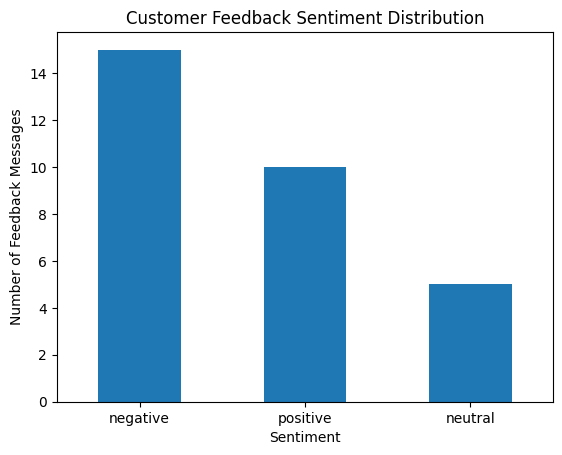

In [3]:
sentiment_counts = df["sentiment"].value_counts()

print("Sentiment Distribution:")
print(sentiment_counts)

sentiment_counts.plot(
    kind="bar",
    title="Customer Feedback Sentiment Distribution"
)

plt.xlabel("Sentiment")
plt.ylabel("Number of Feedback Messages")
plt.xticks(rotation=0)
plt.show()

## 3.3 Text Preprocessing

Before training the model, customer feedback is cleaned.

The preprocessing steps include:

- Convert text to lowercase
- Remove URLs
- Remove numbers
- Remove punctuation
- Remove extra spaces

In [4]:
def clean_text(text):

    text = str(text).lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)

    # Remove numbers
    text = re.sub(r"\d+", "", text)

    # Remove punctuation
    text = text.translate(
        str.maketrans("", "", string.punctuation)
    )

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text


df["clean_feedback"] = df["feedback"].apply(clean_text)

display(
    df[["feedback", "clean_feedback", "sentiment"]].head(10)
)

,feedback,clean_feedback,sentiment
0,Payment is failing,payment is failing,negative
1,The application is very slow,the application is very slow,negative
2,I love the new dashboard,i love the new dashboard,positive
3,Support was very helpful,support was very helpful,positive
4,Login OTP is not arriving,login otp is not arriving,negative
5,The app is slow and payment fails,the app is slow and payment fails,negative
6,The application works perfectly,the application works perfectly,positive
7,Payment was successful,payment was successful,positive
8,I cannot login to my account,i cannot login to my account,negative
9,Customer support did not respond,customer support did not respond,negative


## 3.4 Prepare Features and Target

The cleaned feedback text is used as the input feature.

The sentiment column is used as the target variable.

In [5]:
X = df["clean_feedback"]
y = df["sentiment"]

print("Input Features:", X.shape)
print("Target:", y.shape)

print("\nSentiment Classes:")
print(y.unique())

Input Features: (30,)
Target: (30,)

Sentiment Classes:
['negative' 'positive' 'neutral']


## 3.5 Train-Test Split

The dataset is divided into:

- 75% training data
- 25% testing data

The training data is used to train the model, while the testing data is used to evaluate its performance.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 22
Testing Samples: 8


## 3.6 TF-IDF Feature Extraction

TF-IDF is used to convert the cleaned customer feedback into numerical feature vectors.

Both individual words and two-word phrases are considered using unigram and bigram features.

In [7]:
vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2)
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("TF-IDF conversion completed.")

print("Training TF-IDF Shape:", X_train_tfidf.shape)
print("Testing TF-IDF Shape:", X_test_tfidf.shape)

TF-IDF conversion completed.
Training TF-IDF Shape: (22, 88)
Testing TF-IDF Shape: (8, 88)


## 3.7 Train Logistic Regression Model

Logistic Regression is used as the sentiment classification algorithm.

The model learns patterns in customer feedback and predicts whether the sentiment is positive, negative, or neutral.

In [8]:
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(
    X_train_tfidf,
    y_train
)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


## 3.8 Predict Customer Sentiment

The trained model is used to predict sentiment for the unseen testing data.

In [9]:
y_pred = model.predict(X_test_tfidf)

print("Sentiment predictions generated successfully.")

results = pd.DataFrame({
    "Actual Sentiment": y_test.values,
    "Predicted Sentiment": y_pred
})

display(results)

Sentiment predictions generated successfully.


,Actual Sentiment,Predicted Sentiment
0,negative,negative
1,positive,negative
2,positive,negative
3,neutral,negative
4,negative,negative
5,positive,negative
6,negative,negative
7,negative,negative


## 3.9 Model Accuracy

Accuracy measures the percentage of correctly classified customer feedback messages.

In [10]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(f"Sentiment Model Accuracy: {accuracy:.4f}")
print(f"Sentiment Model Accuracy: {accuracy * 100:.2f}%")

Sentiment Model Accuracy: 0.5000
Sentiment Model Accuracy: 50.00%


## 3.10 Classification Report

The classification report provides:

- Precision
- Recall
- F1-score
- Support

These metrics help evaluate the performance of the sentiment classifier.

In [11]:
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

CLASSIFICATION REPORT
              precision    recall  f1-score   support

    negative       0.50      1.00      0.67         4
     neutral       0.00      0.00      0.00         1
    positive       0.00      0.00      0.00         3

    accuracy                           0.50         8
   macro avg       0.17      0.33      0.22         8
weighted avg       0.25      0.50      0.33         8



## 3.11 Confusion Matrix

A confusion matrix shows the actual and predicted sentiment classes.

It helps identify which sentiment classes are correctly classified and where classification errors occur.

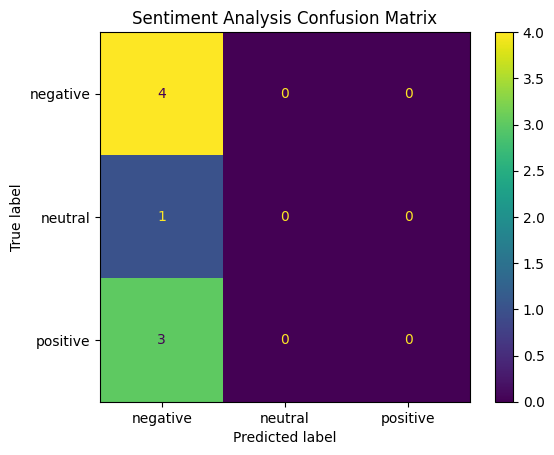

In [12]:
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=model.classes_
)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

display.plot()

plt.title("Sentiment Analysis Confusion Matrix")
plt.show()

## 3.12 Test with New Customer Feedback

Let's test the trained sentiment model with new customer feedback.

In [15]:
new_feedback = [
    "The application is very slow",
    "I love the new dashboard",
    "Payment keeps failing"
]

clean_new_feedback = [
    clean_text(text)
    for text in new_feedback
]

new_feedback_tfidf = vectorizer.transform(
    clean_new_feedback
)

predicted_sentiments = model.predict(
    new_feedback_tfidf
)

prediction_results = pd.DataFrame({
    "Feedback": new_feedback,
    "Predicted Sentiment": predicted_sentiments
})

display(prediction_results)

TypeError: 'ConfusionMatrixDisplay' object is not callable

## 3.13 Conclusion

The sentiment analysis system successfully:

1. Loaded customer feedback
2. Cleaned the text
3. Converted text into TF-IDF features
4. Trained a Logistic Regression classifier
5. Predicted customer sentiment
6. Evaluated the model using accuracy, precision, recall and F1-score
7. Visualized the confusion matrix
8. Tested new customer feedback

The trained model can classify customer feedback into positive, negative, and neutral sentiments.